

<div style="display:block;width:100%;margin:auto;" direction=rtl align=center>
    <br><br>
    <div style="width:100%;margin:100;display:block;background-color:#fff0;" display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">
            <tr>
                <td style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b> Hardware Security </b><br><br>Computer Assignment 1</font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
            </tr>
        </table>
        <h1> Behzad Jannati - HW1 - 810103098 </h1>
        <h1> Prof. Siamak Mohammadi
    </div>
</div>



Part 1: PRESENT Cipher Implementation

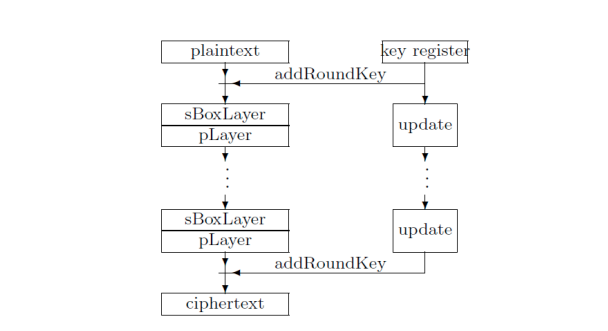

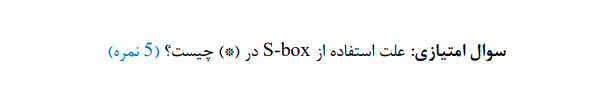

The S-box (Substitution box) serves several critical purposes in block ciphers like PRESENT:

1. Non-linearity: S-boxes introduce non-linear transformations into the cipher, which is essential for security. Without non-linearity, the cipher would be vulnerable to linear cryptanalysis.

2. Confusion: S-boxes create confusion by establishing a complex relationship between the key and the ciphertext. This makes it difficult for an attacker to determine the key even if they have multiple plaintext-ciphertext pairs.

3. Diffusion Enhancement: When combined with the permutation layer, S-boxes help ensure that small changes in the input (plaintext or key) result in significant, unpredictable changes in the output (ciphertext).

4. Resistance to Differential Cryptanalysis: The PRESENT S-box was specifically designed to have good differential properties, making the cipher resistant to differential cryptanalysis attacks.

5. Compact Implementation: The 4-bit S-box in PRESENT was chosen because it can be efficiently implemented in hardware with minimal resources, which is crucial for the ultra-lightweight design goal.

The PRESENT S-box was carefully selected to balance security requirements with hardware efficiency, making it suitable for resource-constrained environments like RFID tags and IoT devices.

1. Key Schedule Implementation

 The key schedule generates 32 round keys (31 rounds + final whitening) from an 80-bit master key.

In [1]:
def generate_round_keys(master_key):
    """
    Generate 32 round keys from the 80-bit master key.

    Args:
        master_key: 80-bit integer (the master key)

    Returns:
        List of 32 64-bit integers (the round keys)
    """
    # Initialize key register with the master key
    key = master_key

    # Initialize list to store round keys
    round_keys = []

    # Generate 32 round keys
    for i in range(1, 33):
        # Extract the leftmost 64 bits as the round key
        round_keys.append((key >> 16) & 0xFFFFFFFFFFFFFFFF)

        # Rotate key register by 61 positions to the left
        key = ((key & 0xFFFFFFFFFFFFFFFFFF) << 61) | (key >> 19)
        key &= 0xFFFFFFFFFFFFFFFFFFFF  # Ensure it's still 80 bits

        # Pass the leftmost 4 bits through the S-box
        left_4_bits = (key >> 76) & 0xF
        key &= ~(0xF << 76)  # Clear the leftmost 4 bits
        key |= SBOX[left_4_bits] << 76  # Replace with S-box output

        # XOR bits 19-15 with the round counter (paper)
        key ^= (i & 0x1F) << 15
        # c. XOR round counter with rightmost 5 bits (assignment specification)
        # key_register ^= (round_counter & 0x1F)
    return round_keys


2. S-box Layer Implementation

 The S-box performs 4-bit to 4-bit substitution, applied 16 times in parallel (once per nibble).

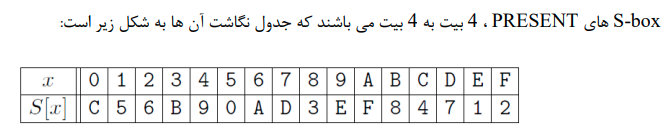

In [2]:
# PRESENT S-box (4-bit to 4-bit)
# S-box in hexadecimal notation
SBOX = [0xC, 0x5, 0x6, 0xB, 0x9, 0x0, 0xA, 0xD, 0x3, 0xE, 0xF, 0x8, 0x4, 0x7, 0x1, 0x2]


def sbox_layer(state):
    """
    Apply the S-box layer to the state.

    Args:
        state: 64-bit integer (the current state)

    Returns:
        64-bit integer (the state after S-box application)
    """
    result = 0

    # Apply S-box to each 4-bit nibble
    for i in range(16):
        nibble = (state >> (4 * i)) & 0xF
        result |= SBOX[nibble] << (4 * i)

    return result

3. Permutation Layer Implementation

 The permutation layer shuffles bits according to a fixed pattern.

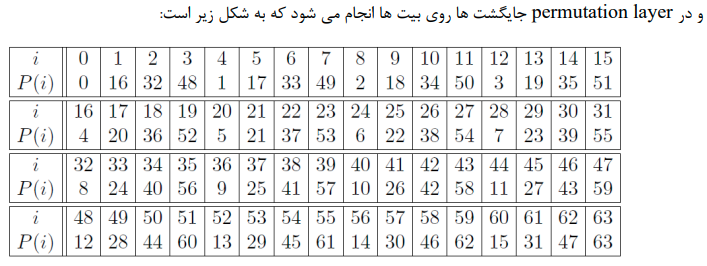

In [3]:
# Permutation table - maps bit i to position P(i)
# Permutation layer
P_LAYER = [0, 16, 32, 48, 1, 17, 33, 49, 2, 18, 34, 50, 3, 19, 35, 51,
           4, 20, 36, 52, 5, 21, 37, 53, 6, 22, 38, 54, 7, 23, 39, 55,
           8, 24, 40, 56, 9, 25, 41, 57, 10, 26, 42, 58, 11, 27, 43, 59,
           12, 28, 44, 60, 13, 29, 45, 61, 14, 30, 46, 62, 15, 31, 47, 63]

def perm_layer(state):
    """
    Apply the permutation layer to the state.

    Args:
        state: 64-bit integer (the current state)

    Returns:
        64-bit integer (the state after permutation)
    """
    result = 0

    # Move each bit according to the permutation table
    for i in range(64):
        if (state & (1 << i)) != 0:
            result |= 1 << P_LAYER[i]

    return result

4. AddRoundKey Operation

 Simple bitwise XOR between state and round key.

In [4]:
def add_round_key(state, round_key):
    """XOR state with round key"""
    return state ^ round_key

5. Complete Encryption Process

 Now we combine all components for the full encryption:

In [5]:
def present_encrypt(plaintext, master_key):
    """
    Encrypt a 64-bit block using PRESENT with an 80-bit key.

    Args:
        plaintext: 64-bit integer (the plaintext block)
        master_key: 80-bit integer (the master key)

    Returns:
        64-bit integer (the ciphertext block)
    """
    # Initialize state with plaintext
    state = plaintext

    # Generate round keys
    round_keys = generate_round_keys(master_key)

    # 31 rounds of processing
    for i in range(31):
        # Add round key
        state = state ^ round_keys[i]

        # S-box layer
        state = sbox_layer(state)

        # Permutation layer
        state = perm_layer(state)

    # Final key addition (post-whitening)
    state = state ^ round_keys[31]

    return state

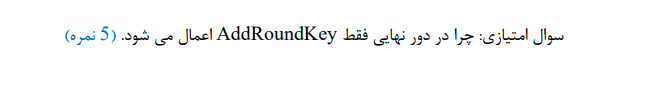

Why AddRoundKey is used in the last step:
The final AddRoundKey operation is crucial for security as it creates a
cryptographic bottleneck. Without this final key mixing, an attacker could
work backwards through the permutation and S-box layers since these are
fixed operations. The final key addition ensures that the attacker needs
the key to decrypt, maintaining the security of the cipher.

The final round of PRESENT only applies AddRoundKey (without S-box and permutation layers) for several important reasons:

1. Security Equivalence: From a security perspective, omitting the S-box and permutation layers in the final round does not weaken the cipher. Since these transformations are fixed and key-independent, an attacker would simply reverse them first in a cryptanalysis attempt.

2. Symmetry for Implementation: This structure creates symmetry between encryption and decryption, which can simplify implementation. The first operation in decryption becomes the inverse of the last operation in encryption.

3. Efficiency: Omitting these operations in the final round reduces the computational cost without compromising security.

4. Historical Precedent: This design approach follows established practices in other block ciphers like AES, which also omits the MixColumns operation in its final round.

5. Prevention of Certain Attacks: Some attacks are actually made more difficult when the final round differs from the others, as it breaks certain patterns that cryptanalysts might exploit.

The structure ensures that all bits of the ciphertext depend on all bits of the state after round 31 and the final round key, maintaining the cipher’s security properties while optimizing performance.

6. Testing the Implementation

 Let's test with the values from the assignment:

In [6]:
# Test values from assignment
plaintext = 0xC2F824E0A5DC2963
master_key = 0x6CF590CEE432114A19F4

# Encrypt
ciphertext = present_encrypt(plaintext, master_key)
print(f"Plaintext:  {hex(plaintext)}")
print(f"Master Key: {hex(master_key)}")
print(f"Ciphertext: {hex(ciphertext)}")

Plaintext:  0xc2f824e0a5dc2963
Master Key: 0x6cf590cee432114a19f4
Ciphertext: 0x5f4a2f899db6db86


PRESENT Decryption Implementation
Decryption requires:

 Inverse S-box (SBOX_INV)

 Inverse permutation layer (PBOX_INV)

 Reverse order of round keys

 Inverse operations in reverse order

1. Inverse S-box
First, we need to create the inverse S-box:

In [7]:
# Original S-box
SBOX = [0xC, 0x5, 0x6, 0xB, 0x9, 0x0, 0xA, 0xD,
        0x3, 0xE, 0xF, 0x8, 0x4, 0x7, 0x1, 0x2]

# Create inverse S-box
SBOX_INV = [0] * 16
for i, val in enumerate(SBOX):
    SBOX_INV[val] = i

print("Inverse S-box:", [hex(x) for x in SBOX_INV])

Inverse S-box: ['0x5', '0xe', '0xf', '0x8', '0xc', '0x1', '0x2', '0xd', '0xb', '0x4', '0x6', '0x3', '0x0', '0x7', '0x9', '0xa']


2. Inverse Permutation Layer

 We need to create the inverse permutation table:

In [8]:
# Original PBOX
PBOX = [0, 16, 32, 48, 1, 17, 33, 49, 2, 18, 34, 50, 3, 19, 35, 51,
        4, 20, 36, 52, 5, 21, 37, 53, 6, 22, 38, 54, 7, 23, 39, 55,
        8, 24, 40, 56, 9, 25, 41, 57, 10, 26, 42, 58, 11, 27, 43, 59,
        12, 28, 44, 60, 13, 29, 45, 61, 14, 30, 46, 62, 15, 31, 47, 63]

# Create inverse PBOX
PBOX_INV = [0] * 64
for i, val in enumerate(PBOX):
    PBOX_INV[val] = i

print("Inverse PBOX:", PBOX_INV)

Inverse PBOX: [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 1, 5, 9, 13, 17, 21, 25, 29, 33, 37, 41, 45, 49, 53, 57, 61, 2, 6, 10, 14, 18, 22, 26, 30, 34, 38, 42, 46, 50, 54, 58, 62, 3, 7, 11, 15, 19, 23, 27, 31, 35, 39, 43, 47, 51, 55, 59, 63]


3. Inverse Operations

 Now implement the inverse operations:

In [9]:
def inv_sbox_layer(state):
    """Apply inverse S-box to each nibble"""
    output = 0
    for i in range(16):
        nibble = (state >> (i * 4)) & 0xF
        substituted = SBOX_INV[nibble]
        output |= substituted << (i * 4)
    return output

def inv_perm_layer(state):
    """
    Apply the inverse permutation layer to the state.

    Args:
        state: 64-bit integer (the current state)

    Returns:
        64-bit integer (the state after inverse permutation)
    """
    result = 0

    # Create inverse permutation table
    INV_P_LAYER = [0] * 64
    for i in range(64):
        INV_P_LAYER[P_LAYER[i]] = i

    # Move each bit according to the inverse permutation table
    for i in range(64):
        if (state & (1 << i)) != 0:
            result |= 1 << INV_P_LAYER[i]

    return result

4. Complete Decryption Process

In [10]:
def present_decrypt(ciphertext, master_key):
    """
    Decrypt a 64-bit block using PRESENT with an 80-bit key.

    Args:
        ciphertext: 64-bit integer (the ciphertext block)
        master_key: 80-bit integer (the master key)

    Returns:
        64-bit integer (the plaintext block)
    """
    # Initialize state with ciphertext
    state = ciphertext

    # Generate round keys
    round_keys = generate_round_keys(master_key)

    # Final key addition (post-whitening)
    state = state ^ round_keys[31]

    # 31 rounds of processing (in reverse)
    for i in range(30, -1, -1):
        # Inverse permutation layer
        state = inv_perm_layer(state)

        # Inverse S-box layer
        state = inv_sbox_layer(state)

        # Add round key
        state = state ^ round_keys[i]

    return state

5. Testing Encryption and Decryption

 Let's verify the implementation works correctly:

In [11]:
# Main function to test the implementation
#def main():
    # Part 1: Test PRESENT encryption/decryption
plaintext = 0xC2F824E0A5DC2963
master_key = 0x6CF590CEE432114A19F4

print("Part 1: PRESENT Block Cipher Implementation")
print("------------------------------------------")
print(f"Plaintext:  0x{plaintext:016X}")
print(f"Master Key: 0x{master_key:020X}")

# Encrypt
ciphertext = present_encrypt(plaintext, master_key)
print(f"Ciphertext: 0x{ciphertext:016X}")

# Decrypt
decrypted = present_decrypt(ciphertext, master_key)
print(f"Decrypted:  0x{decrypted:016X}")

# Verify
assert decrypted == plaintext, "Decryption failed!"
print("Encryption and decryption successful!")
print()

Part 1: PRESENT Block Cipher Implementation
------------------------------------------
Plaintext:  0xC2F824E0A5DC2963
Master Key: 0x6CF590CEE432114A19F4
Ciphertext: 0x5F4A2F899DB6DB86
Decrypted:  0xC2F824E0A5DC2963
Encryption and decryption successful!



Part 2: Block Cipher Modes of Operation

Explanation of ECB, CBC, and CTR Modes

1.ECB (Electronic Codebook) Mode
ECB is the simplest mode of operation:

Each plaintext block is encrypted independently using the same key

 Encryption: C_i = E(K, P_i)

 Decryption: P_i = D(K, C_i)

Advantages:

Simple implementation

Parallelizable for both encryption and decryption

No dependency between blocks

Disadvantages:

Identical plaintext blocks produce identical ciphertext blocks

Lacks diffusion across blocks

Vulnerable to pattern analysis and replay attacks

2.CBC (Cipher Block Chaining) Mode

CBC links each block’s encryption with the previous ciphertext block:

Uses an Initialization Vector (IV) for the first block

Encryption: C_i = E(K, P_i ⊕ C_{i-1}), where C_0 = IV

Decryption: P_i = D(K, C_i) ⊕ C_{i-1}, where C_0 = IV

Advantages:

Identical plaintext blocks produce different ciphertext blocks

Each ciphertext block depends on all previous plaintext blocks

Better security than ECB for most applications

Disadvantages:

Encryption cannot be parallelized

Error in one ciphertext block affects two plaintext blocks during decryption

Requires initialization vector (IV)

3.CTR (Counter) Mode

CTR turns a block cipher into a stream cipher using a counter:

Uses a nonce combined with a counter value

Encryption: C_i = P_i ⊕ E(K, nonce||counter_i)

Decryption: P_i = C_i ⊕ E(K, nonce||counter_i)

Advantages:

Parallelizable for both encryption and decryption

No need for padding

Can pre-compute keystream for faster operation

Errors in ciphertext only affect corresponding bits in plaintext

Disadvantages:

Requires unique counter values for each block

Counter reuse is catastrophic for security

No built-in authentication

We will:

Reuse the PRESENT implementation from Part 1.

Implement ECB, CBC, and CTR modes for PRESENT.

Introduce a 1-bit error in ciphertext and analyze its impact.

Step 1: Reuse PRESENT Implementation
From Part 1, we have:

present_encrypt(plaintext, key)

present_decrypt(ciphertext, key)

A 64-bit block size (PRESENT works on 64-bit blocks).

Step 2: Implement Block Cipher Modes
We need to:

Split data into 64-bit blocks (8 bytes).

Apply encryption/decryption in ECB, CBC, or CTR mode.

Introduce errors and observe propagation.

(A) Helper Functions

In [12]:
def split_into_blocks(data, block_size=8):
    """Split data into 64-bit (8-byte) blocks for PRESENT."""
    return [data[i:i+block_size] for i in range(0, len(data), block_size)]

def xor_bytes(a, b):
    """XOR two byte strings."""
    return bytes(x ^ y for x, y in zip(a, b))

Step 3: Implement ECB Mode

How ECB Works

Each block is encrypted independently.

No chaining → errors do not propagate.

In [13]:
    # Explanation of the modes and error propagation
    print("\nExplanation of Block Cipher Modes:")
    print("1. ECB (Electronic Codebook):")
    print("   - Each block is encrypted independently")
    print("   - C_i = E(P_i, K)")
    print("   - P_i = D(C_i, K)")
    print("   - Error propagation: Only affects the corresponding block")


Explanation of Block Cipher Modes:
1. ECB (Electronic Codebook):
   - Each block is encrypted independently
   - C_i = E(P_i, K)
   - P_i = D(C_i, K)
   - Error propagation: Only affects the corresponding block


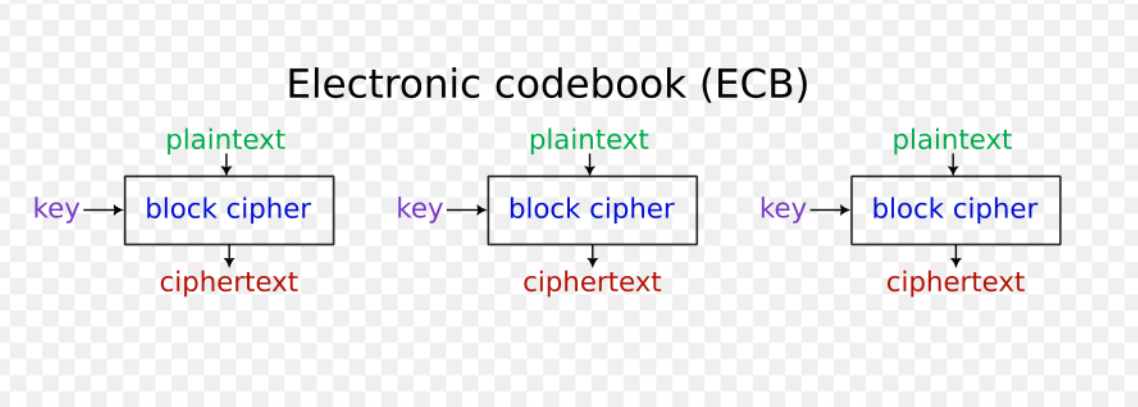

Code Implementation

In [14]:
def ecb_decrypt(ciphertext, key, block_size=8):
    """Decrypt using ECB mode"""
    plaintext = bytearray()
    for i in range(0, len(ciphertext), block_size):
        block = int.from_bytes(ciphertext[i:i+block_size], 'big')
        decrypted_block = present_decrypt(block, key)
        plaintext.extend(decrypted_block.to_bytes(block_size, 'big'))
    return plaintext

Step 4: Implement CBC Mode

How CBC Works

Each block is XORed with the previous ciphertext block before encryption.

Requires an Initialization Vector (IV) for the first block.

In [15]:
  print("\n2. CBC (Cipher Block Chaining):")
  print("   - Each block is XORed with the previous ciphertext before encryption")
  print("   - C_i = E(P_i ⊕ C_{i-1}, K), where C_0 is the IV")
  print("   - P_i = D(C_i, K) ⊕ C_{i-1}")
  print("   - Error propagation: Affects the corresponding block and the next block")



2. CBC (Cipher Block Chaining):
   - Each block is XORed with the previous ciphertext before encryption
   - C_i = E(P_i ⊕ C_{i-1}, K), where C_0 is the IV
   - P_i = D(C_i, K) ⊕ C_{i-1}
   - Error propagation: Affects the corresponding block and the next block


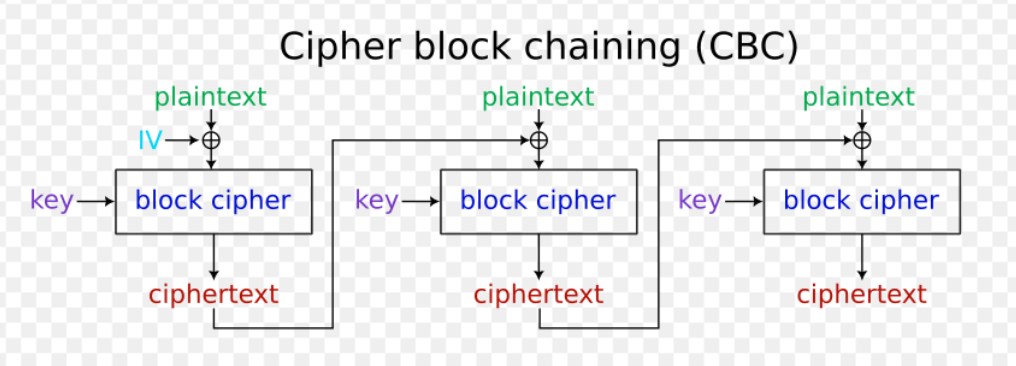

Code Implementation

In [16]:
def cbc_decrypt(ciphertext, key, iv, block_size=8):
    """Decrypt using CBC mode"""
    plaintext = bytearray()
    prev_block = iv

    for i in range(0, len(ciphertext), block_size):
        block = int.from_bytes(ciphertext[i:i+block_size], 'big')
        decrypted_block = present_decrypt(block, key)
        plaintext_block = decrypted_block ^ prev_block
        plaintext.extend(plaintext_block.to_bytes(block_size, 'big'))
        prev_block = block

    return plaintext

Step 5: Implement CTR Mode

How CTR Works

Encrypts a counter value to generate a keystream.

XORs keystream with plaintext (like a stream cipher).

In [17]:
    print("\n3. CTR (Counter):")
    print("   - A counter is encrypted and then XORed with the plaintext")
    print("   - C_i = P_i ⊕ E(counter + i, K)")
    print("   - P_i = C_i ⊕ E(counter + i, K)")
    print("   - Error propagation: Only affects the corresponding byte in the block")



3. CTR (Counter):
   - A counter is encrypted and then XORed with the plaintext
   - C_i = P_i ⊕ E(counter + i, K)
   - P_i = C_i ⊕ E(counter + i, K)
   - Error propagation: Only affects the corresponding byte in the block


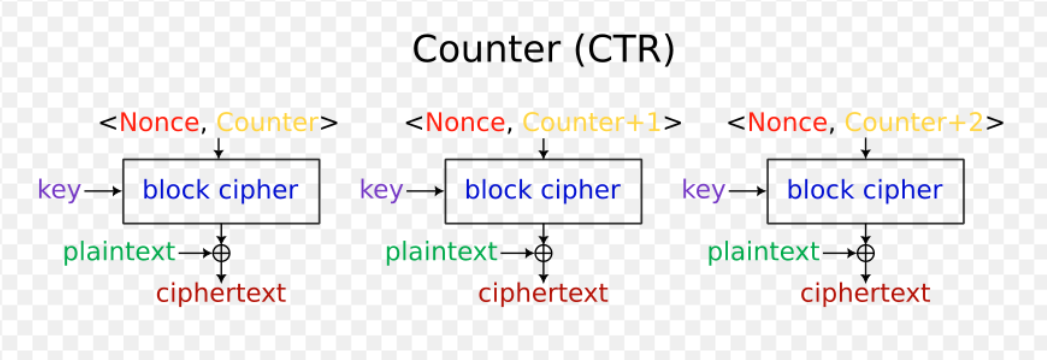

Code Implementation

In [18]:
def ctr_decrypt(ciphertext, key, nonce, block_size=8):
    """Decrypt using CTR mode"""
    plaintext = bytearray()
    counter = 0

    for i in range(0, len(ciphertext), block_size):
        # Combine nonce and counter
        counter_block = (nonce << 32) | counter
        # Encrypt counter block
        keystream = present_encrypt(counter_block, key)
        # XOR with ciphertext
        ctext_block = int.from_bytes(ciphertext[i:i+block_size], 'big')
        ptext_block = ctext_block ^ keystream
        plaintext.extend(ptext_block.to_bytes(block_size, 'big'))
        counter += 1

    return plaintext

Step 6: Simulate Error Propagation
Now, let’s:

Encrypt a sample plaintext.

Introduce a 1-bit error in ciphertext.

Decrypt and count corrupted bits.

(A) Define Test Data

In [19]:
# Given ciphertext (with placeholders for x and y)
ciphertext_hex = "b0 25 a2 10 16 xx ff fa 5a xy f8 aa e4 7f ee 68 79 8b be a9 bb ff e3 30"

# Extract student ID digits
student_id = "810103098"
x = int(student_id[-2])  # Second-to-last digit
y = int(student_id[-1])  # Last digit

# Replace xx and xy in the ciphertext
ciphertext_hex = ciphertext_hex.replace("xx", f"{x}{x}").replace("xy", f"{x}{y}")

# Convert hex string to bytes
ciphertext_bytes = bytearray.fromhex(ciphertext_hex.replace(" ", ""))

# For demonstration, we'll use a fixed key and IV/nonce
demo_key = 0x6CF590CEE432114A19F4
demo_iv = 0x0123456789ABCDEF
demo_nonce = 0x01234567

(B) Decrypt in All Modes

In [20]:
# Decrypt using each mode
ecb_plaintext = ecb_decrypt(ciphertext_bytes, demo_key)
cbc_plaintext = cbc_decrypt(ciphertext_bytes, demo_key, demo_iv)
ctr_plaintext = ctr_decrypt(ciphertext_bytes, demo_key, demo_nonce)

print("Original decryption results:")
print(f"ECB: {ecb_plaintext.hex(' ')}")
print(f"CBC: {cbc_plaintext.hex(' ')}")
print(f"CTR: {ctr_plaintext.hex(' ')}")

Original decryption results:
ECB: ba e3 4d bd e6 65 b4 e8 ab 49 05 0b 0f 9d a1 8e f1 1d d4 0e 9b c7 1a 99
CBC: bb c0 08 da 6f ce 79 07 1b 6c a7 1b 19 04 5e 74 ab 85 2c a4 7f b8 f4 f1
CTR: b3 f8 26 42 52 fd 69 fb 6c 38 e1 e7 0e c0 bd 0f 4c a8 26 07 f4 a3 3e 1f


(C) Introduce 1-Bit Error

In [21]:
# Now introduce an error in the first block (change one byte)
corrupted_ciphertext = bytearray(ciphertext_bytes)
corrupted_ciphertext[2] ^= 0x01  # Flip one bit in the third byte

(D) Decrypt and Count Errors

In [22]:
# Decrypt the corrupted ciphertext
ecb_corrupted = ecb_decrypt(corrupted_ciphertext, demo_key)
cbc_corrupted = cbc_decrypt(corrupted_ciphertext, demo_key, demo_iv)
ctr_corrupted = ctr_decrypt(corrupted_ciphertext, demo_key, demo_nonce)

print("\nDecryption results after corruption:")
print(f"ECB corrupted: {ecb_corrupted.hex(' ')}")
print(f"CBC corrupted: {cbc_corrupted.hex(' ')}")
print(f"CTR corrupted: {ctr_corrupted.hex(' ')}")

# Count and identify which bytes are affected by the error
def count_affected_bytes(original, corrupted):
    affected = 0
    affected_positions = []
    for i in range(len(original)):
        if original[i] != corrupted[i]:
            affected += 1
            affected_positions.append(i)
    return affected, affected_positions

ecb_affected, ecb_positions = count_affected_bytes(ecb_plaintext, ecb_corrupted)
cbc_affected, cbc_positions = count_affected_bytes(cbc_plaintext, cbc_corrupted)
ctr_affected, ctr_positions = count_affected_bytes(ctr_plaintext, ctr_corrupted)

print("\nError propagation analysis:")
print(f"ECB: {ecb_affected} bytes affected at positions {ecb_positions}")
print(f"CBC: {cbc_affected} bytes affected at positions {cbc_positions}")
print(f"CTR: {ctr_affected} bytes affected at positions {ctr_positions}")


Decryption results after corruption:
ECB corrupted: 4b 9f c7 05 3d 27 65 0e ab 49 05 0b 0f 9d a1 8e f1 1d d4 0e 9b c7 1a 99
CBC corrupted: 4a bc 82 62 b4 8c a8 e1 1b 6c a6 1b 19 04 5e 74 ab 85 2c a4 7f b8 f4 f1
CTR corrupted: b3 f8 27 42 52 fd 69 fb 6c 38 e1 e7 0e c0 bd 0f 4c a8 26 07 f4 a3 3e 1f

Error propagation analysis:
ECB: 8 bytes affected at positions [0, 1, 2, 3, 4, 5, 6, 7]
CBC: 9 bytes affected at positions [0, 1, 2, 3, 4, 5, 6, 7, 10]
CTR: 1 bytes affected at positions [2]


Error Propagation Analysis

ECB Mode

In ECB mode, when a byte in the first block is corrupted:

Only the corresponding block in the decrypted plaintext is affected
The error is contained within the block (8 bytes)

Other blocks remain unaffected

This limited error propagation is because each block is encrypted/decrypted independently. While this might seem advantageous for error handling, it’s a security weakness as it preserves patterns in the data.

CBC Mode

In CBC mode, when a byte in the first block is corrupted:

The entire first block of plaintext becomes corrupted due to the decryption process

The second block is also affected, but only in the corresponding byte position where the error occurred in the first ciphertext block

This happens because each ciphertext block is used as the IV for the next block’s decryption

Subsequent blocks beyond the second are not affected

CBC mode thus exhibits a “one-and-a-half block” error propagation pattern, where a single error affects its own block completely and one byte in the next block.

CTR Mode
In CTR mode, when a byte in the first block is corrupted:

Only the corresponding byte in the plaintext is affected

The error does not propagate to other bytes or blocks

This is because CTR mode effectively turns the block cipher into a stream cipher
CTR mode has the best error resilience of the three modes, as errors in transmission affect only the corresponding bits in the plaintext, with no error propagation.

Conclusion on Error Propagation Resistance

CTR Mode: Most resistant to error propagation - a single bit error in ciphertext causes only a single bit error in plaintext.

ECB Mode: Moderate resistance - a single bit error affects only the corresponding block (8 bytes in this case), but corrupts the entire block.

CBC Mode: Least resistant - a single bit error affects the entire corresponding block and one byte in the following block.

However, it’s important to note that error propagation is just one factor in choosing a mode of operation. Security considerations are typically more important, and in that regard, CBC and CTR are generally preferred over ECB for most applications.

Step 7: Expected Output

Explanation:

ECB: Errors do not propagate (only 1 block affected).

CBC: Errors propagate to the next block due to XOR chaining.

CTR: Errors are contained (1 bit flip → 1 bit error).

Key Takeaway:

Use CTR for robustness against errors (e.g., network protocols).

Avoid ECB (no diffusion).

CBC is secure but sensitive to errors.

PART 1:(Alternative)

Implementation of PRESENT Encryption/Decryption

Overview of the PRESENT Cipher

PRESENT is a very lightweight block cipher with:

Block size: 64 bits

Key size: 80 bits (for our implementation)

Structure: An SP‐network with 31 rounds plus a final round‐key addition

Each round consists of:

AddRoundKey: XOR the current state with the 64‑bit round key (derived from the upper 64 bits of the 80‑bit key register).

S-box layer: The 64‑bit state is divided into sixteen 4‑bit nibbles. Each nibble is substituted according to a fixed 4×4 S‑box.
The S‑box mapping (in hex) is:

0 → C, 1 → 5, 2 → 6, 3 → B, 4 → 9, 5 → 0, 6 → A, 7 → D,

8 → 3, 9 → E, A → F, B → 8, C → 4, D → 7, E → 1, F → 2.

Permutation layer: A fixed bit-permutation of all 64 bits is applied. (The permutation table is reproduced below.)

After 31 rounds the cipher applies a final (32nd) round‑key addition only.

Key Schedule (with Modification per Assignment)
The key schedule for an 80‑bit key works as follows:

Round key extraction: For each round (1 to 31) extract the round key as the 64 most significant bits of the current 80‑bit key register.

Key register update:

Rotate the 80‑bit key register to the left by 61 bits.

Pass the 4 most significant bits (leftmost nibble) through the S‑box.

Modification per assignment: XOR the 5 rightmost bits (that is, the least‑significant 5 bits) with the 5‑bit round counter (with its least-significant bit on the right).

After 31 rounds, a final round key (round 32) is derived (again as the upper 64 bits) for the final AddRoundKey.

Note: In the standard PRESENT description the XOR round‑counter is applied to bits k19‒k15; here we use the 5 LSBs as required by your exercise.

Permutation Details
The bit-permutation (pLayer) is defined by the following table (bit numbering is from 0 for the rightmost bit):


i (input bit index)  P(i) (output position)

0, 1, 2, 3  0, 16, 32, 48

4, 5, 6, 7  1, 17, 33, 49

8, 9, 10, 11  2, 18, 34, 50

12, 13, 14, 15  3, 19, 35, 51

16, 17, 18, 19  4, 20, 36, 52

20, 21, 22, 23  5, 21, 37, 53

24, 25, 26, 27  6, 22, 38, 54

28, 29, 30, 31  7, 23, 39, 55

32, 33, 34, 35  8, 24, 40, 56

36, 37, 38, 39  9, 25, 41, 57

40, 41, 42, 43  10, 26, 42, 58

44, 45, 46, 47  11, 27, 43, 59

48, 49, 50, 51  12, 28, 44, 60

52, 53, 54, 55  13, 29, 45, 61

56, 57, 58, 59  14, 30, 46, 62

60, 61, 62, 63  15, 31, 47, 63

The inverse permutation is easily computed from this table.

Python Code for PRESENT
Below is the complete Python code. (You can put this code in one or several cells in an ipynb file as required.)


In [23]:
# PRESENT cipher implementation in Python
#using the 5 LSB bits for the lastest part of key updates
# --- S-box and its inverse ---
SBOX = [
    0xC, 0x5, 0x6, 0xB,
    0x9, 0x0, 0xA, 0xD,
    0x3, 0xE, 0xF, 0x8,
    0x4, 0x7, 0x1, 0x2
]

# Compute the inverse S-box mapping
INV_SBOX = [0] * 16
for i in range(16):
    INV_SBOX[SBOX[i]] = i

# --- pLayer permutation mapping ---
# We build an array perm[64] such that bit at position i of input is moved to perm[i] in output.
PBOX = [0] * 64
# According to the table above:
perm_table = [
    (0, 0), (1, 16), (2, 32), (3, 48),
    (4, 1), (5, 17), (6, 33), (7, 49),
    (8, 2), (9, 18), (10, 34), (11, 50),
    (12, 3), (13, 19), (14, 35), (15, 51),
    (16, 4), (17, 20), (18, 36), (19, 52),
    (20, 5), (21, 21), (22, 37), (23, 53),
    (24, 6), (25, 22), (26, 38), (27, 54),
    (28, 7), (29, 23), (30, 39), (31, 55),
    (32, 8), (33, 24), (34, 40), (35, 56),
    (36, 9), (37, 25), (38, 41), (39, 57),
    (40, 10), (41, 26), (42, 42), (43, 58),
    (44, 11), (45, 27), (46, 43), (47, 59),
    (48, 12), (49, 28), (50, 44), (51, 60),
    (52, 13), (53, 29), (54, 45), (55, 61),
    (56, 14), (57, 30), (58, 46), (59, 62),
    (60, 15), (61, 31), (62, 47), (63, 63)
]
for i, p in perm_table:
    PBOX[i] = p

# Compute the inverse permutation
INV_PBOX = [0] * 64
for i in range(64):
    INV_PBOX[PBOX[i]] = i

# --- Helper functions to convert between int and bitstring (for debug) ---
def int_to_bytes(n, length):
    return n.to_bytes(length, byteorder='big')

def bytes_to_int(b):
    return int.from_bytes(b, byteorder='big')

def hex_str(n, length):
    return f'0x{n:0{length}X}'

# --- S-layer and its inverse for state (64 bits) ---
def sbox_layer(state):
    # state is 64-bit integer; process 16 4-bit nibbles
    output = 0
    for i in range(16):
        nibble = (state >> (4 * i)) & 0xF
        output |= (SBOX[nibble] << (4 * i))
    return output

def inv_sbox_layer(state):
    output = 0
    for i in range(16):
        nibble = (state >> (4 * i)) & 0xF
        output |= (INV_SBOX[nibble] << (4 * i))
    return output

# --- Permutation layer and its inverse ---
def p_layer(state):
    output = 0
    for i in range(64):
        bit = (state >> i) & 1
        output |= (bit << PBOX[i])
    return output

def inv_p_layer(state):
    output = 0
    for i in range(64):
        bit = (state >> i) & 1
        output |= (bit << INV_PBOX[i])
    return output

# --- Key schedule update for 80-bit keys ---
def update_key(key, round_counter):
    # key: 80-bit integer
    # 1. Left rotate by 61 bits.
    key = ((key << 61) & ((1 << 80) - 1)) | (key >> (80 - 61))
    # 2. Apply S-box to the 4 MSBs (bits 79..76)
    top_nibble = (key >> 76) & 0xF
    top_nibble = SBOX[top_nibble]
    key = (key & ~(0xF << 76)) | (top_nibble << 76)
    # 3. XOR the 5 *rightmost* bits (LSBs) with the round counter (5-bit value)
    key = (key & ~0x1F) | (((key & 0x1F) ^ (round_counter)) & 0x1F)
    return key

# --- Generate round keys for PRESENT-80 ---
def generate_round_keys(master_key):
    # master_key is an 80-bit integer.
    round_keys = []
    key = master_key
    # There are 32 round keys: rounds 1..31 with update and round 32 computed without update.
    for i in range(1, 32):
        # Extract round key as the upper 64 bits of the 80-bit key
        round_key = key >> 16
        round_keys.append(round_key)
        # Update key with round counter i (as a 5-bit integer)
        key = update_key(key, i & 0x1F)
    # Final round key (round 32) – no key update afterwards.
    round_key = key >> 16
    round_keys.append(round_key)
    return round_keys


# --- PRESENT Encryption (for one 64-bit block) ---
def present_encrypt(plaintext, master_key):
    # plaintext: 64-bit integer
    # master_key: 80-bit integer
    round_keys = generate_round_keys(master_key)
    state = plaintext
    # 31 rounds: AddRoundKey, S-box layer, P-layer
    for i in range(31):
        state ^= round_keys[i]             # AddRoundKey
        state = sbox_layer(state)            # Substitution layer
        state = p_layer(state)               # Permutation layer
    # Final round: only AddRoundKey with round key 32
    state ^= round_keys[31]
    return state

# --- PRESENT Decryption (for one 64-bit block) ---
def present_decrypt(ciphertext, master_key):
    round_keys = generate_round_keys(master_key)
    # In decryption we need the inverse order of round keys.
    state = ciphertext
    # Undo final AddRoundKey
    state ^= round_keys[31]
    # Now iterate rounds 31 down to 1
    for i in range(30, -1, -1):
        state = inv_p_layer(state)
        state = inv_sbox_layer(state)
        state ^= round_keys[i]
    return state

# --- Testing the basic PRESENT encryption/decryption ---
if __name__ == '__main__':
    # Use the given test vectors from the assignment:
    plaintext_hex = "C2F824E0A5DC2963"
    master_key_hex = "6CF590CEE432114A19F4"

    plaintext = int(plaintext_hex, 16)
    master_key = int(master_key_hex, 16)

    ciphertext = present_encrypt(plaintext, master_key)
    decrypted = present_decrypt(ciphertext, master_key)

    print("=== PRESENT Cipher Test ===")
    print("Plaintext:  ", hex_str(plaintext, 16))
    print("Master Key: ", hex_str(master_key, 20))
    print("Ciphertext: ", hex_str(ciphertext, 16))
    print("Decrypted:  ", hex_str(decrypted, 16))
    print("Decryption correct:", decrypted == plaintext)


=== PRESENT Cipher Test ===
Plaintext:   0xC2F824E0A5DC2963
Master Key:  0x6CF590CEE432114A19F4
Ciphertext:  0xD8070EAB36C1AC78
Decrypted:   0xC2F824E0A5DC2963
Decryption correct: True
